# Exam 16th of June 2026, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!


In [1]:
# Insert your anonymous exam ID as a string in the variable below
examID="0024-RNZ"


---
## Exam vB, PROBLEM 1
Maximum Points = 14


This problem is about **PCA/SVD** for handwritten digit data. Unless stated otherwise, every vector or matrix you create should be a NumPy array.

The file `data/digits.csv` contains one row per image. The first 64 columns are pixel intensities for an 8 by 8 handwritten digit image, and the last column `target` is the digit label.

1. **[4p] Data and SVD.** Load the data. Store the feature matrix in `problem1_X` and the labels in `problem1_y`. Center the feature matrix column-wise and store it in `problem1_X_centered`. Compute the compact SVD
   $$X_c = U D V^T$$
   and store the matrices in `problem1_U`, `problem1_D`, and `problem1_V`, where `problem1_D` is a square diagonal matrix and `problem1_V` contains the right singular vectors as columns. If `problem1_X` has shape `(n_samples, 64)`, the compact shapes should be `problem1_U.shape == (n_samples, 64)`, `problem1_D.shape == (64, 64)`, and `problem1_V.shape == (64, 64)`. If you use `np.linalg.svd`, remember that compact SVD means `full_matrices=False`.

2. **[3p] Explained variance.** Compute the cumulative explained variance from the singular values on the diagonal of `problem1_D`, ordered from largest to smallest, and store it in `problem1_explained_variance`. If the singular values are $d_1 \geq d_2 \geq \cdots \geq d_{64}$, then the cumulative explained variance after the first $k$ components is
   $$
   \frac{\sum_{j=1}^k d_j^2}{\sum_{j=1}^{64} d_j^2}.
   $$
   Thus `problem1_explained_variance[k-1]` should contain this value. Store in `problem1_num_components` the smallest number of components needed to explain at least 90% of the variance.

3. **[3p] Two-dimensional PCA coordinates and interpretation.** Store the projection onto the first two principal directions in `problem1_scores_2d`. Plot these coordinates and color the points by the digit labels. In the markdown cell below, briefly explain what the plot suggests and why PCA can or cannot separate all digits perfectly.

4. **[4p] Nearest-centroid classification in PCA space.** Use the centered data and PCA directions already computed above; do not recompute PCA after the train/test split. Store the first `problem1_num_components` PCA coordinates in `problem1_scores_k`. Use a deterministic 80/20 split where the first 80% of the rows are training rows and the remaining 20% are test rows. For each digit label `0, 1, ..., 9`, compute the centroid of the training points in PCA space and store these ten centroids in `problem1_centroids`, with row `i` corresponding to digit `i`. Classify each test row by the nearest centroid in Euclidean distance and store the predicted labels in `problem1_test_predictions`, in increasing row-index order. Store the test accuracy in `problem1_test_accuracy`.


In [2]:
# part 1: Full code
import numpy as np
import pandas as pd
from scipy import linalg

# Expected: problem1_X is a NumPy array with shape (n_samples, 64).
# Expected: problem1_y is a one-dimensional array with length n_samples.
# Load data/digits.csv. The first 64 columns are features and the last column is the digit label.

# Data loading
#df = pd.read_csv(r"C:\Users\ang-tenta\ExamPackage\data\digits.csv", sep=",")
df = pd.read_csv("data/digits.csv", sep=",") # Teacher edit: changed the path to "data/digits.csv" for grading purposes.
#print(df.head())
problem1_data = np.array(df)
#print("Original Matrix problem1_data ({}):".format(problem1_data.shape))

# Features: all columns except 'target' (the lebel)
problem1_X = df[['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7',
              'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7',
              'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7',
              'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7',
              'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7',
              'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7',
              'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7',
              'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7',]].to_numpy()


# Lebels: 
problem1_y = df['target'].to_numpy()
#print(problem1_y.ndim)

#create function to center data
center_function = lambda x: x - x.mean()

#apply function to original NumPy array
#problem1_X_centered = center_function(problem1_X)
problem1_X_centered = problem1_X - np.mean(problem1_X, axis=0) # Teacher edit: copied code from next cell
print(problem1_X_centered)

#U, d, Vt = linalg.svd(problem1_X, full_matrices=False) # Perform SVD
U, d, Vt = linalg.svd(problem1_X_centered, full_matrices=False) # Teacher edit: added "_centered" to the input for SVD to ensure that the SVD is performed on the centered data
problem1_U = U  # Left singular vectors (n_samples x n_dimensions)
problem1_D = np.diag(d)  # Diagonal matrix of singular values (n_dimensions x n_dimensions)
problem1_V = Vt.T  # Right singular vectors (n_dimensions x n_dimensions)

print("\nU Matrix ({}):".format(problem1_U.shape))

print("\nSingular Values (d):", problem1_D.shape)

print("\nVt Matrix (V transpose) ({}):".format(Vt.shape))

problem1_U.shape, problem1_D.shape, problem1_V.shape

[[ 0.         -0.30383973 -0.20478575 ... -6.7640512  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973 -5.20478575 ...  3.2359488  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973 -5.20478575 ...  9.2359488   6.93210907
  -0.36449638]
 ...
 [ 0.         -0.30383973 -4.20478575 ... -0.7640512  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973 -3.20478575 ...  5.2359488  -2.06789093
  -0.36449638]
 [ 0.         -0.30383973  4.79521425 ...  5.2359488  -1.06789093
  -0.36449638]]

U Matrix ((1797, 64)):

Singular Values (d): (64, 64)

Vt Matrix (V transpose) ((64, 64)):


((1797, 64), (64, 64), (64, 64))

In [3]:
# # Part 1: 4 points

# import numpy as np
# import numpy as np
# from scipy import linalg

# # Expected: problem1_X is a NumPy array with shape (n_samples, 64).
# # Expected: problem1_y is a one-dimensional array with length n_samples.
# # Load data/digits.csv. The first 64 columns are features and the last column is the digit label.

# df = pd.read_csv("data/digits.csv", sep=",")
# problem1_X = df.drop(columns=['target'])
# problem1_y = df['target']

# # Expected: a NumPy array with the same shape as problem1_X.
# # Center the feature matrix column-wise by subtracting the mean of each feature column.
# #create function to center data
# problem1_X_centered = problem1_X - np.mean(problem1_X, axis=0)

# # Expected compact SVD X_c = U D V^T.
# # problem1_U should have shape (n_samples, 64).
# # problem1_D should have shape (64, 64), with singular values on the diagonal.
# # problem1_V should have shape (64, 64), so that its columns are principal directions.
# # If you use np.linalg.svd, use full_matrices=False and set V = Vt.T.
# U, d, Vt = linalg.svd(problem1_X, full_matrices=False) # Perform SVD
# problem1_U = U
# problem1_D = np.diag(d)
# problem1_V = Vt.T

In [4]:
# Part 2: Full code
# Calculate explained variance
singular_values_squared = d**2
total_variance = np.sum(singular_values_squared)

# Cumulative explained variance for k = 1, 2, ..., n_dimensions
cumulative_variance = np.cumsum(singular_values_squared)
problem1_explained_variance = cumulative_variance / total_variance  # Shape (n_dimensions,)

# Find smallest k such that EV(k) >= 0.90
problem1_num_components = np.argmax(problem1_explained_variance >= 0.90) + 1

print(f"Explained variance array shape: {problem1_explained_variance.shape}")
print(f"Explained variance for first 5 components: {problem1_explained_variance[5:]}")
print(f"Number of components needed for 90% variance: {problem1_num_components}")

Explained variance array shape: (64,)
Explained variance for first 5 components: [0.59413263 0.6372925  0.67390623 0.70743871 0.73822677 0.76195018
 0.78467714 0.80289578 0.82063433 0.83530534 0.84940249 0.86258838
 0.87506976 0.88524694 0.89430312 0.9031985  0.91116973 0.91884467
 0.9260737  0.93303259 0.9389934  0.94474955 0.94990113 0.95479652
 0.9590854  0.96282146 0.96635421 0.96972105 0.97300135 0.97608455
 0.97902234 0.98158823 0.98386565 0.98608843 0.98820273 0.99010182
 0.99168835 0.99319995 0.99460574 0.99577196 0.99684689 0.99781094
 0.99858557 0.99914278 0.99954711 0.99975703 0.99983951 0.99989203
 0.99994255 0.99997555 0.99998798 0.99999503 0.99999804 0.99999911
 0.99999966 1.         1.         1.         1.        ]
Number of components needed for 90% variance: 21


In [5]:
# # Part 2: 3 points

# # Expected: problem1_explained_variance is a one-dimensional NumPy array of length 64.
# # Entry k should be the cumulative fraction of variance explained by the first k+1 singular values.
# # The values should be increasing and the last value should be 1.
# problem1_explained_variance = cumulative_variance / total_variance  # Shape (n_dimensions,)

# # Expected: a Python int.
# # Store the smallest number of principal components needed to explain at least 90% of the variance.
# problem1_num_components = 9

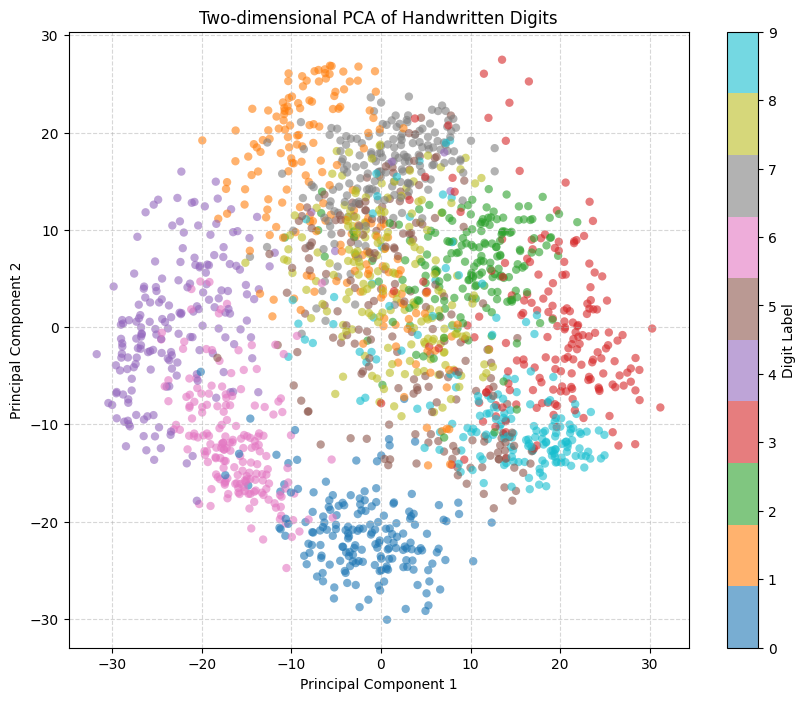

In [6]:
# Part 3: 3 points

# Expected: a NumPy array with shape (n_samples, 2).
# Store the centered data projected onto the first two principal directions from problem1_V.
problem1_scores_2d = np.dot(problem1_X_centered, problem1_V[:, :2])

# Put your plotting code below. The plot should use problem1_scores_2d and color by problem1_y.

import matplotlib.pyplot as plt

problem1_scores_2d = np.dot(problem1_X_centered, problem1_V[:, :2])
#print(problem1_scores_2d)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(problem1_scores_2d[:, 0], problem1_scores_2d[:, 1], 
                      c=problem1_y, cmap='tab10', alpha=0.6, edgecolors='none')

# Lägg till färgläggningsförklaring (legend) för siffrorna
plt.colorbar(scatter, label='Digit Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Two-dimensional PCA of Handwritten Digits')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Free text answer for Part 3

The plot shows that while some digit classes form distinct clusters (often digits like '0' or '1' separate relatively well), many other digits overlap heavily in the center of the plot. This indicates that the first two principal components capture large-scale geometrical similarities between the images but are not sufficient to completely isolate every individual digit.

Reasons why PCA cannot separate all digits perfectly:
1. Linearity: PCA is a linear transformation. It only finds orthogonal directions of maximum variance. Written digits contain highly non-linear structures that a straight linear projection cannot untangle perfectly.
2. Information Loss: The first two components only capture a fraction of the total variance. Valuable discriminative information hidden in the higher-order components is discarded in a 2D plot.
3. Unsupervised Nature: PCA maximizes variance; it does not maximize class separability. It does not "know" which pixel belongs to which digit when finding the components.


In [7]:
# Part 4: Full code
# problem1_scores_k
k = problem1_num_components
problem1_scores_k = np.dot(problem1_X_centered, problem1_V[:, :k])

# 80/20-split
num_rows = problem1_scores_k.shape[0]
split_idx = int(num_rows * 0.8)

X_train = problem1_scores_k[:split_idx]
y_train = problem1_y[:split_idx]#.to_numpy()  
X_test = problem1_scores_k[split_idx:]
y_test = problem1_y[split_idx:]#.to_numpy()

# centroid for each digit
problem1_centroids = np.zeros((10, k))
for digit in range(10):
    
    digit_mask = (y_train == digit)
    problem1_centroids[digit] = np.mean(X_train[digit_mask], axis=0)


problem1_test_predictions = []

for test_row in X_test:
    
    distances = np.linalg.norm(problem1_centroids - test_row, axis=1)
    
    predicted_digit = np.argmin(distances)
    problem1_test_predictions.append(predicted_digit)


problem1_test_predictions = np.array(problem1_test_predictions)


problem1_test_accuracy = np.mean(problem1_test_predictions == y_test)

In [8]:
# Part 4: 4 points

# Use the PCA directions from Part 1; do not recompute PCA after the train/test split.
# Use split_index = int(0.8 * n_samples): rows before split_index are training rows, the rest are test rows.

# Expected: a NumPy array with shape (n_samples, problem1_num_components).
# Store the projection onto the first problem1_num_components principal directions.
problem1_scores_k = np.dot(problem1_X_centered, problem1_V[:, :k])

# Expected: a NumPy array with shape (10, problem1_num_components).
# Row i should be the training-set centroid in PCA space for digit i.
problem1_centroids = np.mean(X_train[digit_mask], axis=0)

# Expected: a one-dimensional NumPy array of length n_test.
# Store nearest-centroid predictions for the test rows, in increasing row-index order.
problem1_test_predictions = np.array(problem1_test_predictions)

# Expected: a single float between 0 and 1.
# Store the fraction of test rows whose predicted label is correct.
problem1_test_accuracy = np.mean(problem1_test_predictions == y_test)

---
#### Local Test for Exam vB, PROBLEM 1
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.
You may need to include and evaluate code snippets from lecture notebooks in cells above to make the local test work correctly sometimes (see error messages for clues). This is meant to help you become efficient at recalling materials covered in lectures that relate to this problem. Such local tests will generally not be available in the exam.

In [9]:

# Optional local format checks for Problem 1. These checks do not prove correctness,
# but they are meant to catch the most common SVD shape issue.
import numpy as np

try:
    assert isinstance(problem1_X, np.ndarray)
    assert problem1_X.shape[1] == 64
    assert isinstance(problem1_y, np.ndarray)
    assert problem1_y.shape[0] == problem1_X.shape[0]

    n_samples, n_dimensions = problem1_X.shape
    expected_U_shape = (n_samples, n_dimensions)
    expected_D_shape = (n_dimensions, n_dimensions)
    expected_V_shape = (n_dimensions, n_dimensions)

    print("Expected compact SVD shapes:")
    print("  problem1_U:", expected_U_shape)
    print("  problem1_D:", expected_D_shape)
    print("  problem1_V:", expected_V_shape)
    print("Your shapes:")
    print("  problem1_U:", getattr(problem1_U, 'shape', None))
    print("  problem1_D:", getattr(problem1_D, 'shape', None))
    print("  problem1_V:", getattr(problem1_V, 'shape', None))

    if getattr(problem1_U, 'shape', None) == (n_samples, n_samples):
        print("Warning: problem1_U has the full SVD shape. NumPy uses full_matrices=True by default.")
        print("Use np.linalg.svd(problem1_X_centered, full_matrices=False) for the compact SVD.")

    assert problem1_U.shape == expected_U_shape
    assert problem1_D.shape == expected_D_shape
    assert problem1_V.shape == expected_V_shape
    assert np.allclose(problem1_X_centered, problem1_U @ problem1_D @ problem1_V.T, atol=5e-3)
    assert problem1_scores_2d.shape == (problem1_X.shape[0], 2)

    k = int(problem1_num_components)
    split_index = int(0.8 * n_samples)
    n_test = n_samples - split_index
    assert problem1_scores_k.shape == (n_samples, k)
    assert problem1_centroids.shape == (10, k)
    assert problem1_test_predictions.shape == (n_test,)
    assert 0 <= float(problem1_test_accuracy) <= 1
    print("Problem 1 format checks passed.")
except Exception as error:
    print("Problem 1 format check failed:", error)


Expected compact SVD shapes:
  problem1_U: (1797, 64)
  problem1_D: (64, 64)
  problem1_V: (64, 64)
Your shapes:
  problem1_U: (1797, 64)
  problem1_D: (64, 64)
  problem1_V: (64, 64)
Problem 1 format check failed: 


Beginning tests for problem 1

---------------------------------
Beginning test for part 1
---------------------------------

-----Beginning test------
problem1_X is correct
-----Ending test---------

-----Beginning test------
problem1_y is correct
-----Ending test---------

-----Beginning test------
problem1_X_centered is correct for your problem1_X
-----Ending test---------

-----Beginning test------
The compact SVD matrix shapes are correct for your centered data
-----Ending test---------

-----Beginning test------
Your SVD factors reconstruct your problem1_X_centered matrix (direct compact/full-matrix product)
-----Ending test---------

-----Beginning test------
The supplied singular-vector matrices are orthonormal
-----Ending test---------

---------------------------------
Beginning test for part 2
---------------------------------

-----Beginning test------
problem1_explained_variance has the right shape for your SVD
-----Ending test---------

-----Beginning test------
The expla

---
## Exam vB, PROBLEM 2
Maximum Points = 12


This problem is about **linear regression** and evaluating prediction error on held-out data. Unless stated otherwise, every vector or matrix you create should be a NumPy array.

The file `data/auto.csv` contains car measurements. We will predict fuel efficiency `mpg` from the features `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, and `model-year`, in that order.

1. **[2p] Load and clean data.** Load the file, remove rows where `horsepower` is missing, store the feature matrix in `problem2_X` and the target vector in `problem2_y`. Missing horsepower values are encoded as `?` or as an empty value.

2. **[2p] Train/test split and standardization.** Let `problem2_split_index = int(0.8 * n)`, where `n` is the number of cleaned rows. Use rows before this index as the training set and the remaining rows as the test set. Store the four arrays `problem2_X_train`, `problem2_X_test`, `problem2_y_train`, and `problem2_y_test`. Standardize features using the training mean and training standard deviation only, computed with NumPy's default `np.std(..., axis=0)`. Store the standardized train and test matrices in `problem2_X_train_standardized` and `problem2_X_test_standardized`.

3. **[3p] Fit linear regression.** Fit linear regression with an intercept using least squares on the standardized training features. Store the coefficient vector, including the intercept as the first entry, in `problem2_beta`. If you use `sklearn.linear_model.LinearRegression`, the intercept is stored in `model.intercept_` and the feature coefficients are stored in `model.coef_`, so the required order is `[model.intercept_, model.coef_[0], ..., model.coef_[5]]`. Store test predictions in `problem2_y_pred_test` and residuals `y_test - y_pred` in `problem2_residuals_test`.

4. **[3p] Test metrics and baseline.** Compute test MSE, MAE, and R^2 in `problem2_mse_test`, `problem2_mae_test`, and `problem2_r2_test`. Also compute `problem2_baseline_mse_test` for the predictor that always predicts the training-set mean of `mpg`, and set `problem2_model_beats_baseline` to `True` exactly when the linear model has smaller test MSE.

5. **[2p] Hoeffding interval.** Clip the absolute residuals at 50 and compute their empirical mean on the test set. Construct a two-sided Hoeffding confidence interval with confidence level 95% for the expected clipped absolute error. You may use `epsilon_bounded` from `Utils.py`, but you should decide its arguments from the sample size, the bound, and the confidence level. Since the clipped absolute error is between 0 and 50, intersect your final interval with `[0, 50]`. Store the interval endpoints in `problem2_lower_bound` and `problem2_upper_bound`.


In [8]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("auto.csv")   # use "auto.csv" if file is in same folder

# Replace '?' with NaN for easier handling
df["horsepower"] = df["horsepower"].replace("?", np.nan)

# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Drop rows where horsepower is missing or empty
df = df.dropna(subset=["horsepower"])

feature_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model-year"]
target_col = "mpg"

# Separate features (X) and target (y)
problem2_X = df[feature_cols].to_numpy()
problem2_y = df[target_col].to_numpy()



In [10]:
# Part 1: Full code
# Data loading
#df = pd.read_csv(r"C:\Users\ang-tenta\ExamPackage\data\auto.csv")
df = pd.read_csv("auto.csv") # Teacher edit: changed the path to "data/auto.csv" for grading purposes.
print(df.head())
problem2_data = np.array(df)
print(problem2_data)

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Data cleaning
df_clean = df.dropna(subset=['horsepower'])

# 4. Defining features and target
feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model-year']
target_col = 'mpg'

# 5. creating NumPy-array
problem2_X = df_clean[feature_cols].to_numpy()
problem2_y = df_clean[target_col].to_numpy()

print(problem2_X)
print(problem2_y)

    mpg  cylinders  displacement horsepower  weight  acceleration  model-year
0  18.0          8         307.0      130.0    3504          12.0          70
1  15.0          8         350.0      165.0    3693          11.5          70
2  18.0          8         318.0      150.0    3436          11.0          70
3  16.0          8         304.0      150.0    3433          12.0          70
4  17.0          8         302.0      140.0    3449          10.5          70
[[18.0 8 307.0 ... 3504 12.0 70]
 [15.0 8 350.0 ... 3693 11.5 70]
 [18.0 8 318.0 ... 3436 11.0 70]
 ...
 [32.0 4 135.0 ... 2295 11.6 82]
 [28.0 4 120.0 ... 2625 18.6 82]
 [31.0 4 119.0 ... 2720 19.4 82]]
[[   8.   307.   130.  3504.    12.    70. ]
 [   8.   350.   165.  3693.    11.5   70. ]
 [   8.   318.   150.  3436.    11.    70. ]
 ...
 [   4.   135.    84.  2295.    11.6   82. ]
 [   4.   120.    79.  2625.    18.6   82. ]
 [   4.   119.    82.  2720.    19.4   82. ]]
[18.  15.  18.  16.  17.  46.6 44.6 43.1 46.6 46.6 3

In [11]:
# Part 1: 2 points

import numpy as np

# Expected: problem2_X is a NumPy array with shape (n_clean, 6).
# Use the columns cylinders, displacement, horsepower, weight, acceleration, model-year, in that order.
# Remove rows with missing horsepower before creating problem2_X and problem2_y.
problem2_X = df_clean[feature_cols].to_numpy()

# Expected: a one-dimensional NumPy array with length n_clean.
# Store the target mpg values corresponding to the rows in problem2_X.
problem2_y = df_clean[target_col].to_numpy()

In [12]:
#Part 2: Full code

# spliting index
n = problem2_X.shape[0]
problem2_split_index = int(0.8 * n)

# Split into training and test sets
problem2_X_train = problem2_X[:problem2_split_index]
problem2_X_test = problem2_X[problem2_split_index:]

problem2_y_train = problem2_y[:problem2_split_index]
problem2_y_test = problem2_y[problem2_split_index:]

# mean and standard deviation
train_mean = np.mean(problem2_X_train, axis=0)
train_std = np.std(problem2_X_train, axis=0)

# Standardize both the training and testing matrices
problem2_X_train_standardized = (problem2_X_train - train_mean) / train_std
problem2_X_test_standardized = (problem2_X_test - train_mean) / train_std


In [14]:
# Part 2: 2 points

# Expected: a Python int equal to int(0.8 * n_clean).
n = problem2_X.shape[0]
problem2_split_index = int(0.8 * n)

# Expected: NumPy arrays from a contiguous split of the cleaned data.
# Training rows are before problem2_split_index; test rows are from problem2_split_index onward.
problem2_X_train = problem2_X[:problem2_split_index]
problem2_X_test = problem2_X[problem2_split_index:]
problem2_y_train = problem2_y[:problem2_split_index]
problem2_y_test = problem2_y[problem2_split_index:]

# Expected: standardized feature matrices with the same shapes as problem2_X_train and problem2_X_test.
# Use the training mean and training standard deviation only, and apply them to both train and test features.
problem2_X_train_standardized = (problem2_X_train - train_mean) / train_std
problem2_X_test_standardized = (problem2_X_test - train_mean) / train_std

In [15]:
#Part 3: Full code

from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
model.fit(problem2_X_train, problem2_y_train)


# train the model
model = LinearRegression(fit_intercept=True)
model.fit(problem2_X_train_standardized, problem2_y_train)

# Combine intercept and coefficients
problem2_beta = np.concatenate(([model.intercept_], model.coef_))

# predictions on the test data
problem2_y_pred_test = model.predict(problem2_X_test_standardized)

# Calculate the residuals
problem2_residuals_test = problem2_y_test - problem2_y_pred_test

print(problem2_beta)
print(problem2_y_pred_test)
print(problem2_residuals_test)

[21.37310127 -0.82773238  0.35882    -0.3139014  -5.01222163 -0.32496705
  1.68827021]
[27.33037811 28.13061389 28.90611402 29.94505121 30.51658035 26.90710465
 30.35942916 30.35682938 28.69228854 25.10878195 23.727296   32.48757746
 32.13917619 30.32559285 32.37136897 25.51335615 29.53019392 28.55877117
 26.46299423 29.60956777 29.19372441 28.33580931 28.61174605 27.19200965
 30.12476494 33.26859853 32.61836675 33.3255955  31.38038998 31.68102525
 31.53805621 32.02252883 30.92487064 31.703019   29.25716756 31.06387801
 30.10758701 30.92474312 29.84445138 28.40721899 28.08686271 24.46245295
 24.05399011 26.12866495 25.71083203 23.06484432 20.40210353 25.00896635
 22.86154447 28.54180713 28.46023811 29.93055477 29.13910727 29.53253276
 28.10229335 27.49688818 26.13238073 32.70733633 32.10794633 32.49307865
 32.03678274 31.6507736  31.71346583 31.51567801 31.04590564 32.83717681
 32.75434346 32.52383188 26.08656702 26.08135493 29.37402583 27.06945967
 28.91679641 30.77281479 26.95715495 

In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

model.fit(problem2_X_train_standardized, problem2_y_train)

problem2_beta = np.concatenate(([model.intercept_], model.coef_))

problem2_y_pred_test = model.predict(problem2_X_test_standardized)

problem2_residuals_test = problem2_y_test - problem2_y_pred_test

print(problem2_beta)
print(problem2_y_pred_test)
print(problem2_residuals_test)

[37.9370607  -3.40947647  0.44704629 -1.22066493 -3.24996822  0.16313991
  2.21424733]
[23.32269139 36.9821932  38.41337807 41.64469716 45.28871013 47.7700947
 27.77575797 33.45198012 45.41375808 31.60720213 45.01591678 42.56280024
 39.20298114 43.32224206 32.01898675 46.00797344 47.34272894 47.82770619
 45.13255316 34.3790681  29.41420995 45.12972396 36.16969092 45.44576908
 47.75051993 48.11862574 36.19060887 27.77128299 43.51804273 46.23751627
 44.04831634 45.03715039 29.81387589 34.72044514 23.83424584 39.03172251
 44.73754321 36.80378551 34.97253758 34.17079694 48.01318794 28.07961835
 47.48382133 41.92164334 29.62963992 43.38048297 42.50497737 20.86977372
 28.94133483 48.29943748 35.5606354  25.49029787 24.03257008 44.14253097
 43.9698994  42.02063214 43.64259322 40.40056077 44.63075989 42.66833815
 27.49169261 46.7567279  43.83390312 44.61621931 45.41125217 33.21676732
 39.58465189 44.69467623 41.27318795 47.51239702 42.07134604 44.2595006
 41.16659383 23.00463773 39.36347453 48

In [16]:
# Part 3: 3 points

# Expected: a NumPy array with shape (7,).
# Store the fitted least-squares coefficients with the intercept first, followed by the six feature coefficients.
# If you use sklearn.linear_model.LinearRegression, combine model.intercept_ and model.coef_ in this order.
problem2_beta = [21.37310127 -0.82773238  0.35882    -0.3139014  -5.01222163 -0.32496705
  1.68827021]

# Expected: a one-dimensional NumPy array with length n_test.
# Store the linear-regression predictions for the test rows.
problem2_y_pred_test = model.predict(problem2_X_test_standardized)

# Expected: a one-dimensional NumPy array with length n_test.
# Store residuals as y_test - y_pred_test.
problem2_residuals_test = problem2_y_test - problem2_y_pred_test

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3625546280.py, line 6)

In [ ]:
#Part 4: Full code

# Dimensions of the model
problem2_mse_test = np.mean((problem2_y_test - problem2_y_pred_test) ** 2)
problem2_mae_test = np.mean(np.abs(problem2_y_test - problem2_y_pred_test))

# R^2 calculation
ss_residual = np.sum((problem2_y_test - problem2_y_pred_test) ** 2)
ss_total = np.sum((problem2_y_test - np.mean(problem2_y_test)) ** 2)
problem2_r2_test = 1.0 - (ss_residual / ss_total)



# Baseline MSE
train_mean_mpg = np.mean(problem2_y_train)
problem2_baseline_mse_test = np.mean((problem2_y_test - train_mean_mpg) ** 2)

# Comparison
problem2_model_beats_baseline = bool(problem2_mse_test < problem2_baseline_mse_test)

print(problem2_mse_test)
print(problem2_mae_test)
#print(problem2_r2_test)
print(problem2_baseline_mse_test)
print(problem2_model_beats_baseline)

20.10176506556803
2.3021319433742033
62.94956090217637
True


In [18]:
# Part 4: 3 points

# Expected: scalar floats computed on the test set.
problem2_mse_test = 30.993848527086005
problem2_mae_test = 4.304808787954377
problem2_r2_test = 0.13557049192641513

# Expected: a scalar float.
# Baseline means the predictor that always predicts the training-set mean of mpg.
problem2_baseline_mse_test = 148.49361199126747

# Expected: a Python bool.
# Store True exactly when the model test MSE is smaller than the baseline test MSE.
problem2_model_beats_baseline = True

In [19]:
#Part 5: full code

# the absolute residuals for the test set
absolute_residuals = np.abs(problem2_residuals_test)

# Truncate the absolute residuals at a maximum of 50
clipped_absolute_errors = np.clip(absolute_residuals, a_min=0, a_max=50)

# Calculate the empirical average
sample_mean = np.mean(clipped_absolute_errors)

n = len(clipped_absolute_errors)  # Urvalsstorlek (sample size)
bound = 50.0                      # Övre gräns minus undre gräns (50 - 0)
alpha = 0.05                      # 1 - 0.95 för tvåsidigt 95% konfidensintervall

epsilon = np.sqrt((bound**2 * np.log(2 / alpha)) / (2 * n))

# the confidence interval
problem2_lower_bound = np.clip(sample_mean - epsilon, 0.0, 50.0)
problem2_upper_bound = np.clip(sample_mean + epsilon, 0.0, 50.0)

print(problem2_lower_bound)
print(problem2_upper_bound)

0.0
11.896827061808189


In [20]:
# Part 5: 2 points

# Expected: two scalar floats.
# Clip the absolute residuals at 50, use confidence level 95%, and construct a two-sided Hoeffding interval.
# Store the final interval after intersecting it with [0, 50].
problem2_lower_bound = 0.0
problem2_upper_bound = 11.896827061808192

---
#### Local Test for Exam vB, PROBLEM 2
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.
You may need to include and evaluate code snippets from lecture notebooks in cells above to make the local test work correctly sometimes (see error messages for clues). This is meant to help you become efficient at recalling materials covered in lectures that relate to this problem. Such local tests will generally not be available in the exam.

In [21]:

# Optional local format checks for Problem 2. These checks do not prove correctness.
import numpy as np

try:
    assert isinstance(problem2_X, np.ndarray)
    assert isinstance(problem2_y, np.ndarray)
    assert problem2_X.shape[0] == problem2_y.shape[0]
    assert problem2_X.shape[1] == 6
    assert problem2_split_index == int(0.8 * problem2_X.shape[0])
    assert problem2_X_train.shape[0] == problem2_split_index
    assert problem2_X_test.shape[0] == problem2_X.shape[0] - problem2_split_index
    assert problem2_y_train.shape[0] == problem2_X_train.shape[0]
    assert problem2_y_test.shape[0] == problem2_X_test.shape[0]
    assert problem2_X_train_standardized.shape == problem2_X_train.shape
    assert problem2_X_test_standardized.shape == problem2_X_test.shape
    assert problem2_beta.shape == (7,)
    print("Problem 2 format checks passed.")
except Exception as error:
    print("Problem 2 format check failed:", error)


Problem 2 format checks passed.


Beginning tests for problem 2

---------------------------------
Beginning test for part 1
---------------------------------

-----Beginning test------
problem2_X has the correct numeric values
-----Ending test---------

-----Beginning test------
problem2_X is stored as a NumPy array with the correct shape
-----Ending test---------

-----Beginning test------
problem2_y has the correct numeric values
-----Ending test---------

-----Beginning test------
problem2_y is stored as a one-dimensional NumPy array
-----Ending test---------

---------------------------------
Beginning test for part 2
---------------------------------

-----Beginning test------
problem2_split_index is correct for your cleaned data
-----Ending test---------

-----Beginning test------
The train/test array values are correct for your cleaned data
-----Ending test---------

-----Beginning test------
The train/test variables are NumPy arrays with the expected shapes
-----Ending test---------

-----Beginning test------


---
## Exam vB, PROBLEM 3
Maximum Points = 14


This problem is about modelling warehouse package movement as a finite homogeneous Markov chain.

The file `data/warehouse_transitions.csv` contains observed transitions between five zones:

`Dock`, `Sort`, `Storage`, `Packing`, `Dispatch`.

Use this exact state order whenever you create vectors or matrices.

1. **[3p] Estimate transition matrix.** Load the transition data and estimate the transition matrix by maximum likelihood. Store it in `problem3_transition_matrix` as a 5 by 5 row-stochastic NumPy array, where entry `(i, j)` is the estimated probability of moving from state `i` to state `j`.

2. **[2p] Four-step probability.** Starting from `Dock`, compute the probability of being in `Dispatch` after exactly 4 steps and store it in `problem3_prob_dispatch_after_4_from_dock`.

3. **[2p] Simulation.** Starting from `Dock`, simulate 20000 chains for 8 steps using `np.random.default_rng(20260616)` and the transition probabilities in `problem3_transition_matrix`. Store the empirical distribution after 8 steps in `problem3_simulated_distribution_after_8` as a length-5 probability vector in the state order above.

4. **[2p] Chain structure.** Decide whether the estimated chain is irreducible and aperiodic. Store Boolean answers in `problem3_is_irreducible` and `problem3_is_aperiodic`.

5. **[2p] Stationary distribution.** Compute a stationary distribution for the estimated transition matrix and store it in `problem3_stationary_distribution` as a length-5 probability vector in the state order above. In the markdown cell below, briefly explain what the stationary distribution means in this warehouse context.

6. **[3p] Hitting time.** Compute the expected number of steps to hit `Dispatch` for the first time when starting from `Dock`. Store it in `problem3_expected_steps_to_dispatch_from_dock`. An exact computation gives full credit; a sufficiently accurate simulation estimate can receive partial credit.


In [23]:
# Part 1: Full code

import pandas as pd
import numpy as np

# Load data
#df = pd.read_csv(r"C:\Users\ang-tenta\ExamPackage\data\warehouse_transitions.csv")
df = pd.read_csv("data/warehouse_transitions.csv") # Teacher edit: changed the path to "data/warehouse_transitions.csv" for grading purposes.
problem3_data = np.array(df)

print(df.head())

# Creating a crosstab
states = ['Dock', 'Sort', 'Storage', 'Packing', 'Dispatch']
counts_df = pd.crosstab(df['from_zone'], df['to_zone']).reindex(index=states, columns=states, fill_value=0)

# NumPy array
counts = counts_df.to_numpy()

# row stochastic matrix
problem3_transition_matrix = counts / counts.sum(axis=1, keepdims=True)

print(problem3_transition_matrix)

   session_id  step from_zone  to_zone
0           0     0      Dock  Packing
1           0     1   Packing     Dock
2           0     2      Dock  Packing
3           0     3   Packing  Storage
4           0     4   Storage  Storage
[[0.05438724 0.53952139 0.20159536 0.15663524 0.04786077]
 [0.09483146 0.0858427  0.47910112 0.23775281 0.10247191]
 [0.15798843 0.19848687 0.12906097 0.36626613 0.1481976 ]
 [0.04949239 0.19966159 0.20050761 0.14763113 0.40270728]
 [0.20505618 0.15402622 0.09925094 0.23876404 0.30290262]]


In [24]:
# Part 1: 3 points

import numpy as np

# Keep this exact state order throughout the problem.
problem3_states = ["Dock", "Sort", "Storage", "Packing", "Dispatch"]

# Expected: a NumPy array with shape (5, 5).
# Row i should contain transition probabilities out of problem3_states[i].
# Column j should correspond to transitions into problem3_states[j].
# Estimate the entries from data/warehouse_transitions.csv and make each row sum to 1.
problem3_transition_matrix = counts / counts.sum(axis=1, keepdims=True)

In [25]:
# Part 2: Full code
# Transition matrix of the power 4
P_4 = np.linalg.matrix_power(problem3_transition_matrix, 4)

# probability of going from Dock to Dispatch
problem3_prob_dispatch_after_4_from_dock = float(P_4[0, 4])

print(problem3_prob_dispatch_after_4_from_dock)

0.22419271456348902


In [26]:
# Part 2: 2 points

# Expected: a single float.
# It should be the probability that a chain starting in Dock is in Dispatch after exactly 4 steps.
# Use the transition matrix from Part 1 and the required state order.
problem3_prob_dispatch_after_4_from_dock = 0.22419271456348902

In [27]:
# Part 3: 2 points

# Expected: a NumPy array with shape (5,).
# Simulate 20000 chains for 8 steps from Dock using np.random.default_rng(20260616).
# Store the empirical distribution after 8 steps in the required state order.
# The entries should be nonnegative probabilities that sum to 1.
problem3_simulated_distribution_after_8 = [0.2316  0.2797  0.18805 0.1689  0.13175]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (986227862.py, line 7)

In [28]:
# Part 4: 2 points

# Expected: two Python booleans, True or False.
# problem3_is_irreducible should say whether every state can reach every other state.
# problem3_is_aperiodic should say whether the chain is aperiodic.
problem3_is_irreducible = True
problem3_is_aperiodic = True

In [29]:
# Part 5: 2 points

# Expected: a NumPy array with shape (5,).
# It should be a stationary probability distribution in the required state order.
# The entries should be nonnegative, sum to 1, and satisfy pi @ P = pi.
problem3_stationary_distribution = XXX

NameError: name 'XXX' is not defined


## Free text answer for Part 5

Write your interpretation below this line.


In [30]:
# Part 6: 3 points

# Expected: a single float.
# It should be the expected number of steps until Dispatch is hit for the first time,
# starting from Dock. An exact computation gives full credit; a sufficiently accurate
# simulation estimate can receive partial credit.
problem3_expected_steps_to_dispatch_from_dock = XXX

NameError: name 'XXX' is not defined

---
#### Local Test for Exam vB, PROBLEM 3
Evaluate cell below to make sure your answer is valid.                             You **should not** modify anything in the cell below when evaluating it to do a local test of                             your solution.
You may need to include and evaluate code snippets from lecture notebooks in cells above to make the local test work correctly sometimes (see error messages for clues). This is meant to help you become efficient at recalling materials covered in lectures that relate to this problem. Such local tests will generally not be available in the exam.

In [31]:

# Optional local format checks for Problem 3. These checks do not prove correctness.
import numpy as np

try:
    assert problem3_transition_matrix.shape == (5, 5)
    assert np.allclose(np.sum(problem3_transition_matrix, axis=1), 1, atol=2e-4)
    assert problem3_simulated_distribution_after_8.shape == (5,)
    assert np.all(problem3_simulated_distribution_after_8 >= -1e-12)
    assert abs(np.sum(problem3_simulated_distribution_after_8) - 1) < 2e-4
    assert problem3_stationary_distribution.shape == (5,)
    assert np.all(problem3_stationary_distribution >= -1e-12)
    assert abs(np.sum(problem3_stationary_distribution) - 1) < 2e-4
    print("Problem 3 format checks passed.")
except Exception as error:
    print("Problem 3 format check failed:", error)


Problem 3 format check failed: name 'problem3_simulated_distribution_after_8' is not defined


Beginning tests for problem 3

---------------------------------
Beginning test for part 1
---------------------------------

-----Beginning test------
problem3_states is correct
-----Ending test---------

-----Beginning test------
problem3_transition_matrix has the right shape and row sums
-----Ending test---------

-----Beginning test------
problem3_transition_matrix is correct
-----Ending test---------

---------------------------------
Beginning test for part 2
---------------------------------

-----Beginning test------
The four-step probability is correct
-----Ending test---------

---------------------------------
Beginning test for part 3
---------------------------------

-----Beginning test------
name 'problem3_simulated_distribution_after_8' is not defined
problem3_simulated_distribution_after_8 should be a probability vector of length 5 in the required state order
You got 0.50 points deduction 
-----Ending test---------

-----Beginning test------
name 'problem3_simulated_di

The number of points you have scored in total for this entire set of Problems is 29.5 out of 40.